# 🐱🐶 Cats vs Dogs — CNN from Scratch

Training a convolutional neural network to classify cats and dogs using PyTorch.  
No pretrained models — everything built from the ground up.

**Pipeline:**
1. Load and explore the dataset
2. Preprocess images with augmentation
3. Build the CNN architecture
4. Train the model
5. Evaluate performance with visualizations

In [1]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Add src to path so we can import our modules
sys.path.append(os.path.join(os.getcwd(), '..'))

from src.model import CatDogCNN, count_parameters
from src.dataset import CatDogDataset, get_train_transforms, get_val_transforms, load_image_paths
from src.utils import (
    train_one_epoch, validate,
    plot_training_curves, plot_confusion_matrix,
    plot_roc_curve, plot_prediction_distribution,
    get_classification_metrics
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load the Dataset

The data should be in a `data/` folder. It can either be:
- Flat: `data/train/cat.0.jpg`, `data/train/dog.0.jpg` (Kaggle format)
- Subfolders: `data/train/cats/`, `data/train/dogs/`

We'll split into train (80%), validation (10%), and test (10%).

In [2]:
# Point this to wherever your images are
DATA_DIR = os.path.join('..', 'data', 'train')

image_paths, labels = load_image_paths(DATA_DIR)

# First split: 80% train, 20% temp (which we'll split into val and test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=SEED, stratify=labels
)

# Second split: 50/50 on the temp set -> 10% val, 10% test overall
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_paths)}")
print(f"  Val:   {len(val_paths)}")
print(f"  Test:  {len(test_paths)}")

Loaded 25000 images from ../data/train
  Cats: 12500, Dogs: 12500

Split sizes:
  Train: 20000
  Val:   2500
  Test:  2500


### Quick look at some sample images

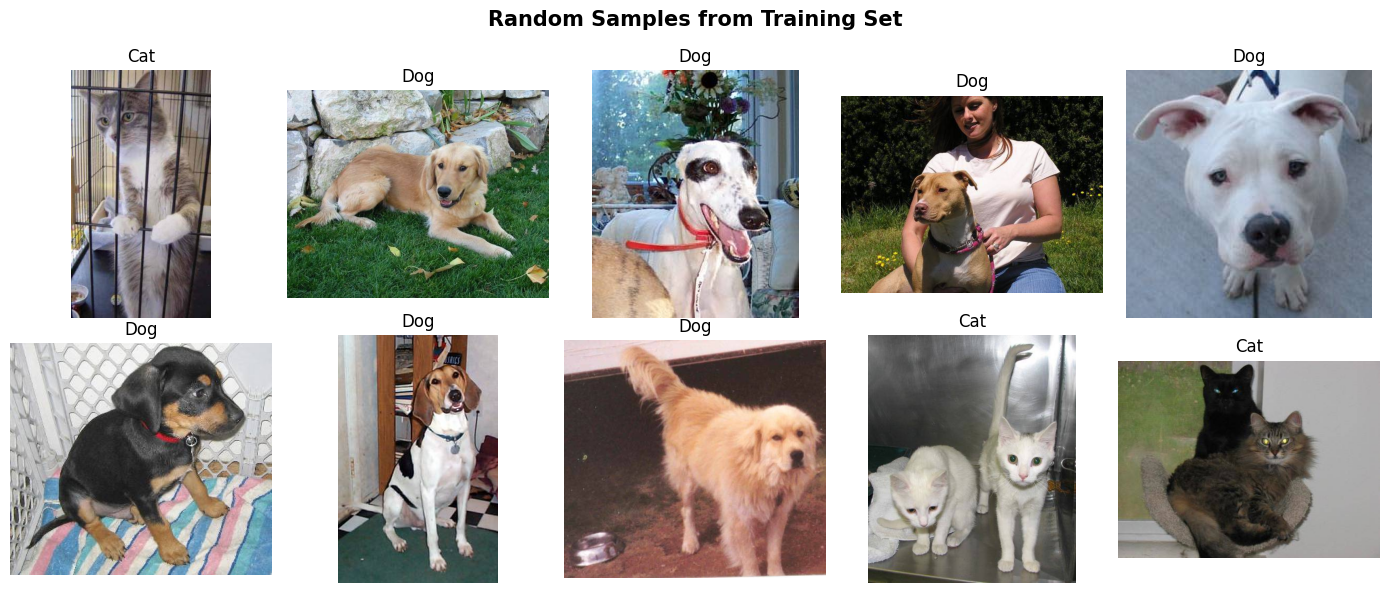

In [3]:
# Show a few random samples
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Random Samples from Training Set", fontsize=15, fontweight='bold')

class_names = ["Cat", "Dog"]
sample_indices = random.sample(range(len(train_paths)), 10)

for i, idx in enumerate(sample_indices):
    row, col = i // 5, i % 5
    img = Image.open(train_paths[idx]).convert('RGB')
    axes[row][col].imshow(img)
    axes[row][col].set_title(class_names[train_labels[idx]], fontsize=12)
    axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('../plots/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Create DataLoaders

Training set gets augmentation (flips, rotation, color jitter).  
Val and test just get resized and normalized.

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_dataset = CatDogDataset(train_paths, train_labels, transform=get_train_transforms(IMG_SIZE))
val_dataset = CatDogDataset(val_paths, val_labels, transform=get_val_transforms(IMG_SIZE))
test_dataset = CatDogDataset(test_paths, test_labels, transform=get_val_transforms(IMG_SIZE))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Verify a batch
sample_imgs, sample_labels = next(iter(train_loader))
print(f"\nBatch shape: {sample_imgs.shape}")
print(f"Labels shape: {sample_labels.shape}")

Train batches: 625
Val batches:   79
Test batches:  79

Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


### Visualize augmented images

Let's see what the augmentation actually does to the images.

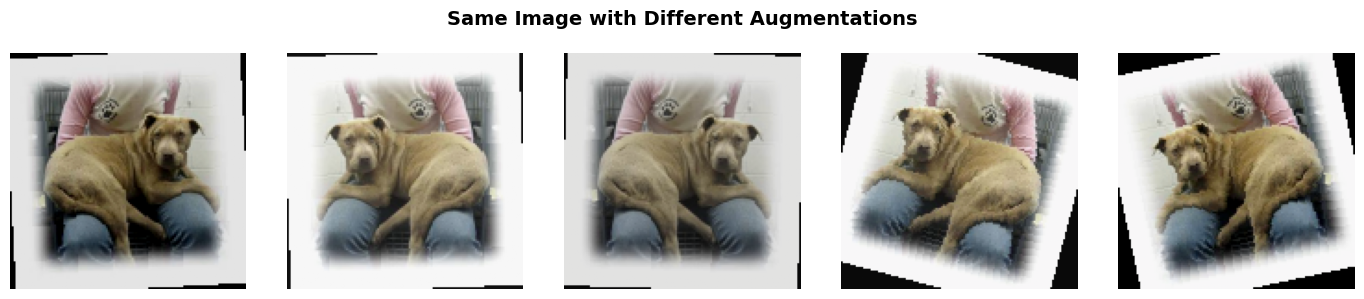

In [5]:
# Show augmented versions of the same image
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle("Same Image with Different Augmentations", fontsize=14, fontweight='bold')

# Unnormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

sample_img_path = train_paths[0]
aug_transform = get_train_transforms(IMG_SIZE)

for i in range(5):
    img = Image.open(sample_img_path).convert('RGB')
    aug_img = aug_transform(img)
    # Undo normalization
    display_img = aug_img * std + mean
    display_img = display_img.clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(display_img)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../plots/augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Build the Model

4 convolutional blocks with batch normalization, followed by a fully connected classifier with dropout.

In [6]:
model = CatDogCNN(dropout_rate=0.5).to(device)

print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")

CatDogCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride

In [7]:
# Hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
PATIENCE = 5  # for early stopping

criterion = nn.BCEWithLogitsLoss()  # handles sigmoid internally
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

## 4. Training Loop

Train with early stopping — if validation loss doesn't improve for `PATIENCE` epochs, we stop.

In [12]:
# Track metrics
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0
best_model_path = '../models/best_model.pth'

# Make sure model directory exists
os.makedirs('../models', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Saved best model (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

print("\nTraining complete!")

Starting training...

Epoch [1/20] Train Loss: 0.7347 | Train Acc: 0.6413 | Val Loss: 0.5610 | Val Acc: 0.7112
  -> Saved best model (val_loss: 0.5610)
Epoch [2/20] Train Loss: 0.5609 | Train Acc: 0.7116 | Val Loss: 0.4745 | Val Acc: 0.7744
  -> Saved best model (val_loss: 0.4745)
Epoch [3/20] Train Loss: 0.5124 | Train Acc: 0.7508 | Val Loss: 0.4312 | Val Acc: 0.7996
  -> Saved best model (val_loss: 0.4312)
Epoch [4/20] Train Loss: 0.4675 | Train Acc: 0.7875 | Val Loss: 0.4702 | Val Acc: 0.7776
Epoch [5/20] Train Loss: 0.4143 | Train Acc: 0.8171 | Val Loss: 0.4307 | Val Acc: 0.7884
  -> Saved best model (val_loss: 0.4307)
Epoch [6/20] Train Loss: 0.3665 | Train Acc: 0.8391 | Val Loss: 0.3459 | Val Acc: 0.8528
  -> Saved best model (val_loss: 0.3459)
Epoch [7/20] Train Loss: 0.3354 | Train Acc: 0.8598 | Val Loss: 0.2649 | Val Acc: 0.8848
  -> Saved best model (val_loss: 0.2649)
Epoch [8/20] Train Loss: 0.3032 | Train Acc: 0.8730 | Val Loss: 0.3185 | Val Acc: 0.8736
Epoch [9/20] Train L

## 5. Evaluate the Model

Load the best checkpoint and run evaluation on the test set.

In [9]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels_arr, test_probs = validate(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

NameError: name 'best_model_path' is not defined

In [ ]:
# loading from json

import torch
from pathlib import Path

# Adjust the path to look one level up from the notebooks folder
best_model_path = '../models/best_model.pth' 

# Safety check: make sure the file actually exists
if not Path(best_model_path).exists():
    print(f"Error: Model file not found at {best_model_path}")
else:
    # Load the state dictionary
    # map_location=device ensures it loads correctly whether you are on CPU or GPU
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    print("Best model loaded and set to evaluation mode!")

## loading the model data after reloading the kernel

In [8]:
import json
import plotly.graph_objects as go # or whatever your plotting function uses

# Load the history back into memory
with open('../models/training_history.json', 'r') as f:
    history = json.load(f)

print("History reloaded successfully!")

History reloaded successfully!


### Training Curves

In [10]:
fig = plot_training_curves(
    history['train_loss'], history['val_loss'],
    history['train_acc'], history['val_acc']
)
fig.write_html('../plots/training_curves.html')
fig.show()

### Confusion Matrix

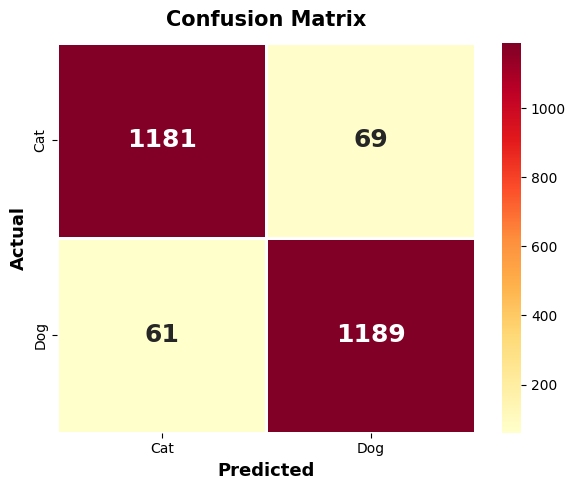

In [20]:
cm_fig = plot_confusion_matrix(test_labels_arr, test_preds)
cm_fig.savefig('../plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### ROC Curve

In [12]:
roc_fig = plot_roc_curve(test_labels_arr, test_probs)
roc_fig.write_html('../plots/roc_curve.html')
roc_fig.show()

NameError: name 'test_labels_arr' is not defined

### Prediction Confidence Distribution

In [22]:
dist_fig = plot_prediction_distribution(test_probs, test_labels_arr)
dist_fig.write_html('../plots/prediction_distribution.html')
dist_fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Classification Report

In [23]:
import pandas as pd

report = get_classification_metrics(test_labels_arr, test_preds)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(3)
print("Classification Report:")
report_df

Classification Report:


,precision,recall,f1-score,support
Cat,0.951,0.945,0.948,1250.000
Dog,0.945,0.951,0.948,1250.000
accuracy,0.948,0.948,0.948,0.948
macro avg,0.948,0.948,0.948,2500.000
weighted avg,0.948,0.948,0.948,2500.000


### Look at some predictions

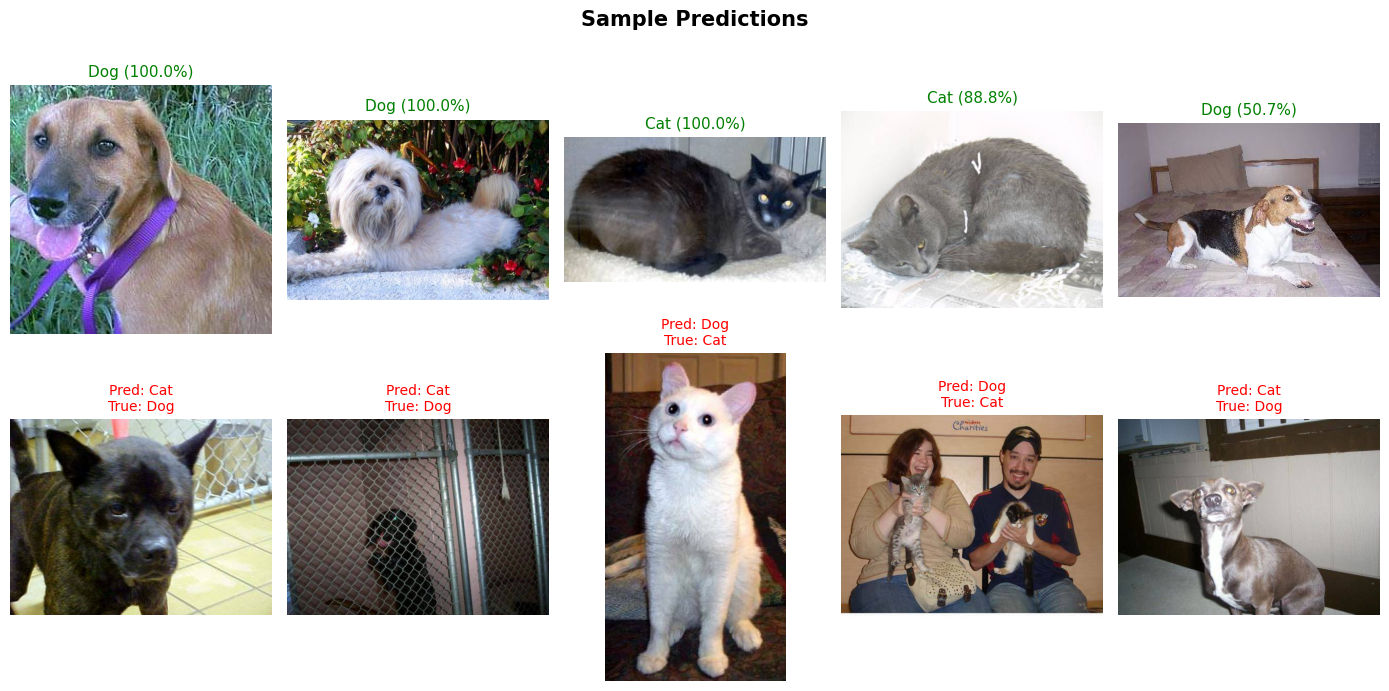

In [24]:
# Show some correct and incorrect predictions
correct_mask = test_preds == test_labels_arr
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle("Sample Predictions", fontsize=15, fontweight='bold')

# Top row: correct predictions
axes[0][0].set_ylabel("Correct ✓", fontsize=13, fontweight='bold', color='green')
correct_indices = np.where(correct_mask)[0][:5]
for i, idx in enumerate(correct_indices):
    img = Image.open(test_paths[idx]).convert('RGB')
    pred_label = class_names[int(test_preds[idx])]
    conf = test_probs[idx] if test_preds[idx] == 1 else 1 - test_probs[idx]
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"{pred_label} ({conf:.1%})", fontsize=11, color='green')
    axes[0][i].axis('off')

# Bottom row: incorrect predictions (if any)
axes[1][0].set_ylabel("Wrong ✗", fontsize=13, fontweight='bold', color='red')
incorrect_indices = np.where(incorrect_mask)[0][:5]
for i, idx in enumerate(incorrect_indices):
    img = Image.open(test_paths[idx]).convert('RGB')
    pred_label = class_names[int(test_preds[idx])]
    true_label = class_names[int(test_labels_arr[idx])]
    axes[1][i].imshow(img)
    axes[1][i].set_title(f"Pred: {pred_label}\nTrue: {true_label}", fontsize=10, color='red')
    axes[1][i].axis('off')

# Hide any unused axes
for row in axes:
    for ax in row:
        if not ax.images:
            ax.axis('off')

plt.tight_layout()
plt.savefig('../plots/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### Save training history for the Streamlit app

In [25]:
import json

# Save training history so the Streamlit app can load it
history_data = {
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_acc': history['train_acc'],
    'val_acc': history['val_acc'],
    'test_loss': test_loss,
    'test_acc': test_acc,
    'test_probs': test_probs.tolist(),
    'test_labels': test_labels_arr.tolist(),
    'test_preds': test_preds.tolist()
}

with open('../models/training_history.json', 'w') as f:
    json.dump(history_data, f)

print("Saved training history to models/training_history.json")
print("Saved best model to models/best_model.pth")
print("\nDone! You can now run the Streamlit app with: streamlit run app.py")

Saved training history to models/training_history.json
Saved best model to models/best_model.pth

Done! You can now run the Streamlit app with: streamlit run app.py
